In [1]:
## Imports

In [2]:
import scanpy as sc
import numpy as np
import scipy as sp
import os, sys
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR, DATA_DIR


In [4]:
d10_lapa = sc.read_h5ad(DATA_DIR / "egfDuod_D10_Lapa_DZ.h5ad")

In [5]:
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    uns: 'X_name'
    layers: 'counts'

In [6]:
d10_lapa.var["mt"] = d10_lapa.var_names.str.startswith("MT-")

In [7]:
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'mt'
    uns: 'X_name'
    layers: 'counts'

In [8]:
d10_lapa.var["ribo"] = d10_lapa.var_names.str.startswith(("RPS", "RPL"))


In [9]:
sc.pp.calculate_qc_metrics(d10_lapa, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

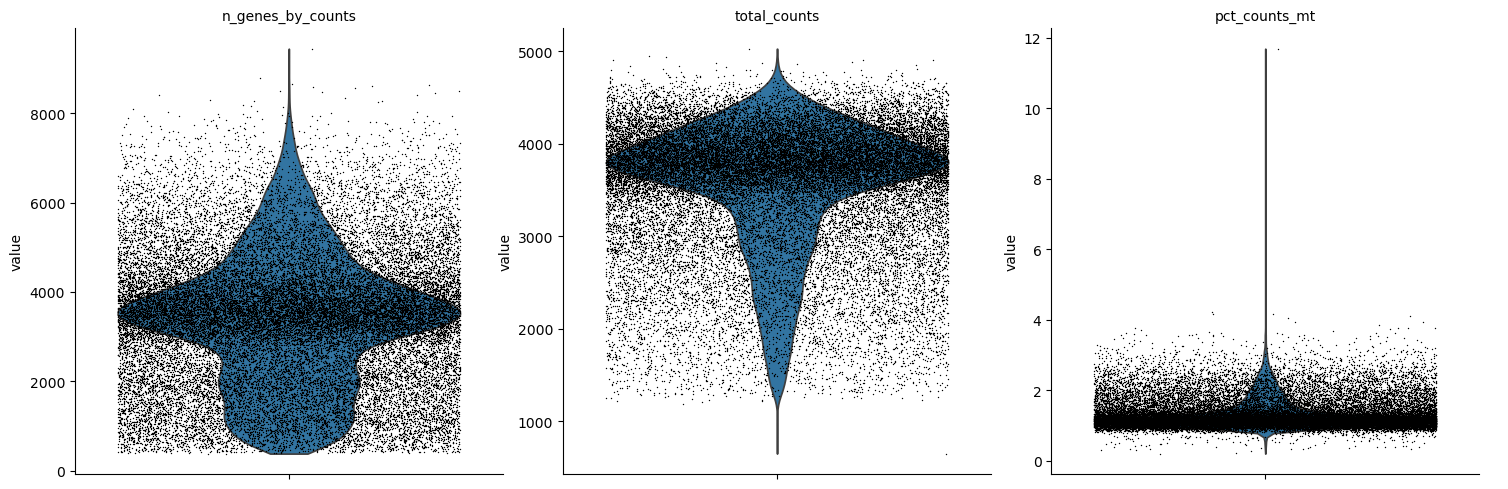

In [10]:
sc.pl.violin(
    d10_lapa,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

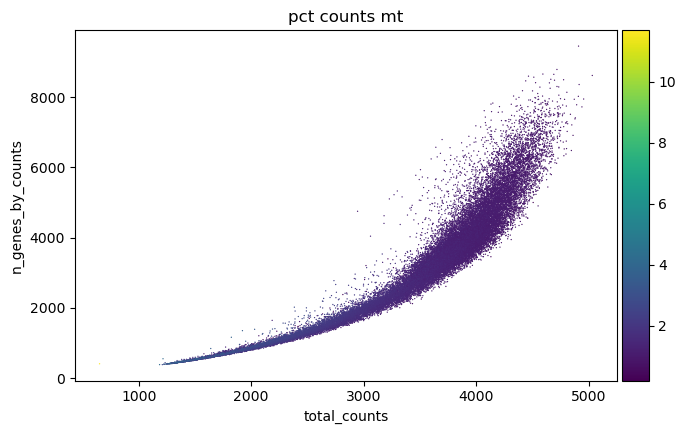

In [11]:
sc.pl.scatter(d10_lapa, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [12]:
d10_lapa.obs[['n_genes_by_counts','total_counts','pct_counts_mt']].describe()


,n_genes_by_counts,total_counts,pct_counts_mt
count,33507.000000,33507.000000,33507.000000
mean,3374.280061,3538.198026,1.325345
std,1485.247400,690.787219,0.428827
min,379.000000,652.269239,0.202120
25%,2307.500000,3237.631449,1.061807
50%,3446.000000,3730.945741,1.184428
75%,4232.000000,3997.354747,1.422449
max,9451.000000,5029.932072,11.687919


In [13]:
sc.pp.scrublet(d10_lapa)

In [14]:
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'X_name', 'scrublet'
    layers: 'counts'

In [18]:
d10_lapa.obs[['doublet_score']].describe()


,doublet_score
count,33507.000000
mean,0.078920
std,0.064987
min,0.002036
25%,0.035449
50%,0.058226
75%,0.100491
max,0.643192


In [19]:
d10_lapa.obs[['predicted_doublet']].describe()


,predicted_doublet
count,33507
unique,1
top,False
freq,33507


In [ ]:
## we need to set the parameter for the threshold of 'predicted doublet', we're failing to do so manually

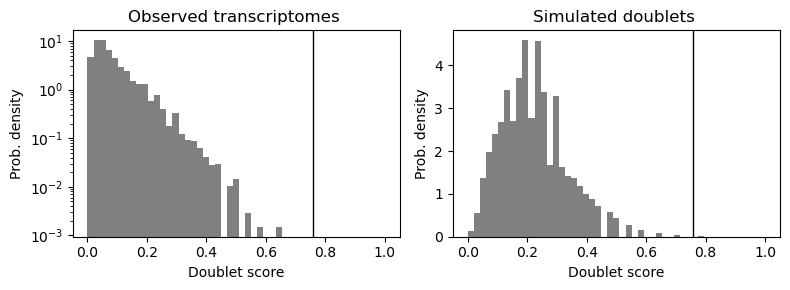

In [23]:
sc.pl.scrublet_score_distribution(d10_lapa)

In [25]:
intermediate_directory = str(ANALYSIS_DIR / "data-objects/qc")
sc.write(f'{intermediate_directory}/doublet_egfDuod_D10_Lapa_DZ.h5ad', d10_lapa)